<a href="https://colab.research.google.com/github/ivanto-vrgs/Distribucion-de-Poisson_LIGV/blob/main/POISSON.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Distribución de Probabilidad de Poisson

## 1. Definición Matemática y Parámetros
La distribución de Poisson es una estructura probabilística discreta que modela el número de eventos independientes que ocurren a una tasa constante dentro de un intervalo continuadamente fijo de tiempo, espacio, área o volumen.

Si definimos a $X$ como la variable aleatoria discreta que contabiliza dichos eventos, se dice que $X$ sigue una distribución de Poisson con parámetro $\lambda > 0$ si su función de masa de probabilidad ($PMF$) está expresada por:

$$P(X = k) = \frac{e^{-\lambda} \lambda^k}{k!}, \quad \forall k \in \{0, 1, 2, \dots\}$$

Donde $\lambda$ representa la tasa promedio de ocurrencia esperada por unidad de medida. Una propiedad analítica fundamental de esta distribución es la equidispersión, donde tanto el valor esperado como la varianza están determinados simétricamente por el mismo parámetro:

$$E[X] = \lambda \quad \text{y} \quad \text{Var}(X) = \lambda$$

---

## 2. Interpretación y Condiciones del Proceso
El núcleo de esta distribución radica en la interpretación de $\lambda$ como una velocidad o frecuencia media. Para que un fenómeno real pueda ser correctamente aproximado mediante este modelo, el sistema debe comportarse como un **Proceso de Poisson**, el cual exige el cumplimiento de tres axiomas:

1. **Estacionariedad:** La probabilidad de que ocurra un evento en un intervalo infinitesimal $dt$ es proporcional a la longitud de dicho intervalo ($\lambda dt$) y no depende del histórico del tiempo.
2. **Independencia (Sin memoria):** El número de eventos que suceden en un periodo determinado es completamente independiente de los eventos que ocurrieron en cualquier otro bloque de tiempo disjunto.
3. **No simultaneidad:** La probabilidad de que acontezcan dos o más eventos de forma estrictamente simultánea en un intervalo de tiempo que tiende a cero es despreciable.

---

## 3. Utilidad y Aplicaciones
La distribución de Poisson es una herramienta indispensable en la investigación de operaciones, la ingeniería de software y la gestión de infraestructura debido a su capacidad para predecir escenarios bajo incertidumbre y optimizar la toma de decisiones:

* **Teoría de Colas (Líneas de Espera):** Permite dimensionar la capacidad de atención en sistemas físicos o virtuales (como cajeros automáticos, salas de urgencias o *call centers*) al modelar la frecuencia de llegada de los usuarios.
* **Tráfico de Redes y Telecomunicaciones:** Ayuda a calcular la probabilidad de saturación de un enrutador o una antena de telefonía celular evaluando el flujo de paquetes de datos o peticiones web por segundo.
* **Gestión de Riesgos y Seguridad:** Es utilizada por compañías de seguros para estimar la cantidad de siniestros automovilísticos anuales o fallas estructurales por kilómetro de obra civil, facilitando el cálculo de primas y costos de mantenimiento.

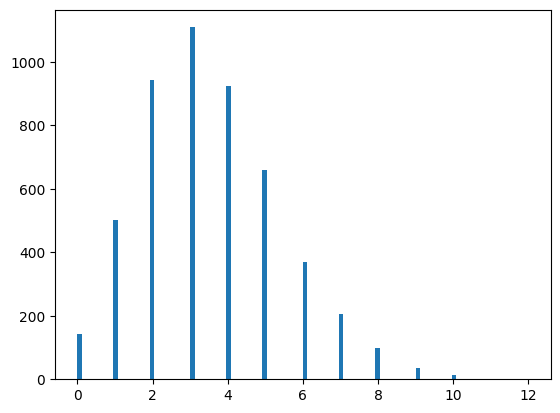

--- VALIDACIÓN ESTADÍSTICA ---
Media Teórica (Lambda): 3.5
Media del Experimento:  3.5230
Varianza del Experimento: 3.5187


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

def generar_poisson_vectorial(lam, num_muestras):
    """
    Genera múltiples variables aleatorias Poisson simultáneamente
    utilizando el método de la transformada inversa vectorizado.
    """
    # Arreglo para almacenar los resultados finales de X
    X = np.zeros(num_muestras, dtype=int)

    # Generamos U ~ U(0,1) para todas las muestras al mismo tiempo
    U = np.random.rand(num_muestras)

    # Inicialización de estados probabilísticos
    p = np.exp(-lam)
    F = np.copy(p)
    i = 0

    # Máscara booleana para identificar cuáles muestras ya terminaron
    por_terminar = np.ones(num_muestras, dtype=bool)

    # El bucle continúa hasta que todas las muestras encuentren su celda acumulada
    while np.any(por_terminar):
        # Si U < F y no ha terminado antes, asignamos el valor actual de i
        condicion_exito = (U < F) & por_terminar
        X[condicion_exito] = i
        por_terminar[condicion_exito] = False

        # Actualización de los valores para la siguiente iteración
        p = (lam / (i + 1)) * p
        F = F + p
        i += 1

    return X

# --- Parámetros de la Simulación ---
lambda_analisis = 3.5
tamano_muestra = 5000

# Ejecución del algoritmo diferente
M = generar_poisson_vectorial(lambda_analisis, tamano_muestra)

# --- Gráfica en Formato Minimalista (Idéntico a tu ejemplo) ---
plt.hist(M, bins=100)
plt.show()

# --- Validación de Resultados en Consola ---
print("--- VALIDACIÓN ESTADÍSTICA ---")
print(f"Media Teórica (Lambda): {lambda_analisis}")
print(f"Media del Experimento:  {np.mean(M):.4f}")
print(f"Varianza del Experimento: {np.var(M):.4f}")